**Перед выполнением ячеек переключитесь на среду выполнения с графическим процессором.**

# **Практическое занятие: Вариационный автоэнкодер (VAE)**

В этом практическом занятии мы реализуем и обучим вариационный автоэнкодер (VAE) на датасете рукописных цифр MNIST. Вы познакомитесь с основными компонентами VAE: энкодером, декодером, репараметризацией и функцией потерь (ELBO). После обучения мы визуализируем результаты: реконструкции, случайные генерации, интерполяции и исследуем влияние гиперпараметров.

👈 *Цель занятия — не просто запустить готовый код, а понять, как устроен VAE внутри, и поэкспериментировать с ним.*

## 1. Импорт библиотек и подготовка данных

Нам понадобятся PyTorch, Torchvision для работы с данными, Matplotlib для визуализации и NumPy.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Устройство (GPU если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1.1 Загрузка датасета MNIST

Мы используем MNIST — 28x28 чёрно-белые изображения цифр. Нормализуем пиксели к интервалу [0,1].

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


Train size: 60000, Test size: 10000


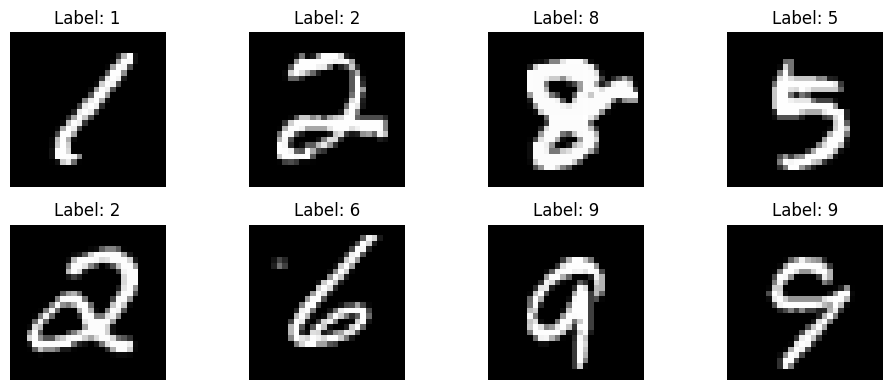

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))  # Не нормализуем, оставляем [0,1] для BCE
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

# Посмотрим на несколько примеров
examples = iter(train_loader)
images, labels = next(examples)
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Определение модели VAE

Класс VAE содержит:
- **Энкодер**: полносвязная сеть, которая преобразует входное изображение (784 пикселя) в параметры распределения $q(z|x)$: среднее `mu` и логарифм дисперсии `log_var`.
- **Reparameterization trick**: позволяет дифференцировать случайный узел: $z = \mu + \sigma \cdot \varepsilon$, где $\varepsilon \sim \mathcal{N}(0, I)$.
- **Декодер**: полносвязная сеть, которая по латентному коду $z$ восстанавливает изображение. На выходе используем сигмоиду, чтобы пиксели были в [0,1].

In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=20):
        super(VAE, self).__init__()

        # Энкодер
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2 * latent_dim)  # выход: mu и log_var
        )

        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # чтобы выход был в [0,1]
        )

        self.latent_dim = latent_dim

    def encode(self, x):
        """Возвращает mu и log_var"""
        h = self.encoder(x)
        mu, log_var = h.chunk(2, dim=-1)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """Репараметризация: z = mu + sigma * eps"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

### 2.1 Функция потерь (ELBO)

Для VAE мы максимизируем нижнюю границу логарифма правдоподобия (ELBO). На практике минимизируем отрицательный ELBO:

$$ \mathcal{L}_{VAE} = -\mathbb{E}_{z\sim q_\phi(z|x)}[\log p_\theta(x|z)] + D_{KL}(q_\phi(z|x) \| p(z)) $$

где $p(z) = \mathcal{N}(0, I)$. Первое слагаемое — reconstruction loss (BCE или MSE), второе — KL-дивергенция между распределением энкодера и стандартным нормальным.

Для нормальных распределений с диагональной ковариацией KL имеет аналитическую форму:

$$ D_{KL} = -\frac{1}{2} \sum_{j=1}^{M} (1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2) $$

In [5]:
def vae_loss(recon_x, x, mu, log_var, beta=1.0):
    """
    recon_x: восстановленное изображение
    x: исходное изображение
    mu, log_var: параметры распределения энкодера
    beta: коэффициент для KL (β-VAE)
    """
    # Reconstruction loss (Binary Cross Entropy, сумма по пикселям и батчу)
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence
    KL = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Усредняем по батчу (или можно оставить сумму, главное — консистентность)
    return (BCE + beta * KL) / x.size(0)

## 3. Обучение VAE

Обучим модель на 10-20 эпохах. Будем логировать значения loss и визуализировать прогресс.

In [6]:
# Параметры
latent_dim = 2
hidden_dim = 256
lr = 1e-3
num_epochs = 15
beta = 1.0  # для обычного VAE β=1

model = VAE(input_dim=784, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

train_losses = []
test_losses = []

Epoch 1: 100%|██████████| 469/469 [00:10<00:00, 46.04it/s]


Epoch 1: Train Loss = 189.2707, Test Loss = 167.5470


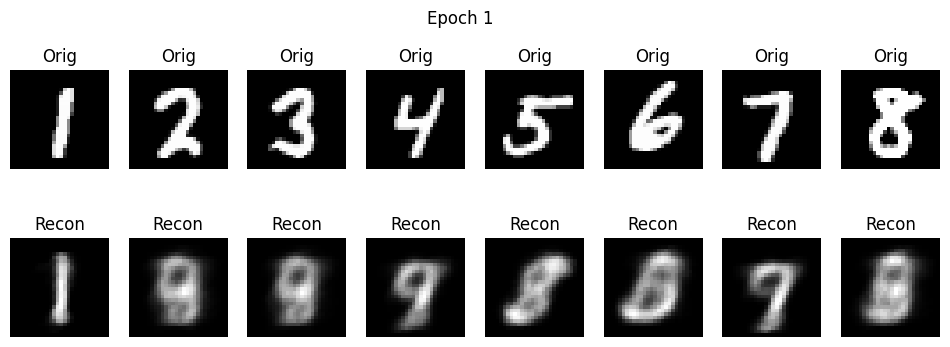

Epoch 2: 100%|██████████| 469/469 [00:07<00:00, 59.39it/s]


Epoch 2: Train Loss = 163.2290, Test Loss = 159.3942


Epoch 3: 100%|██████████| 469/469 [00:07<00:00, 64.97it/s]


Epoch 3: Train Loss = 156.9147, Test Loss = 154.7731


Epoch 4: 100%|██████████| 469/469 [00:07<00:00, 61.20it/s]


Epoch 4: Train Loss = 153.5991, Test Loss = 152.4699


Epoch 5: 100%|██████████| 469/469 [00:07<00:00, 58.88it/s]


Epoch 5: Train Loss = 151.3437, Test Loss = 150.6115


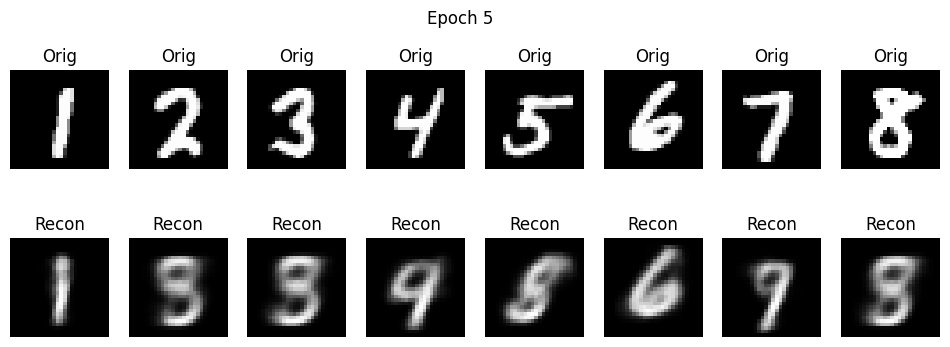

Epoch 6: 100%|██████████| 469/469 [00:08<00:00, 55.48it/s]


Epoch 6: Train Loss = 149.7109, Test Loss = 149.3557


Epoch 7: 100%|██████████| 469/469 [00:07<00:00, 65.66it/s]


Epoch 7: Train Loss = 148.2022, Test Loss = 147.8334


Epoch 8: 100%|██████████| 469/469 [00:07<00:00, 59.49it/s]


Epoch 8: Train Loss = 147.1658, Test Loss = 147.0396


Epoch 9: 100%|██████████| 469/469 [00:08<00:00, 58.07it/s]


Epoch 9: Train Loss = 146.0817, Test Loss = 146.6274


Epoch 10: 100%|██████████| 469/469 [00:07<00:00, 62.73it/s]


Epoch 10: Train Loss = 145.2306, Test Loss = 145.5034


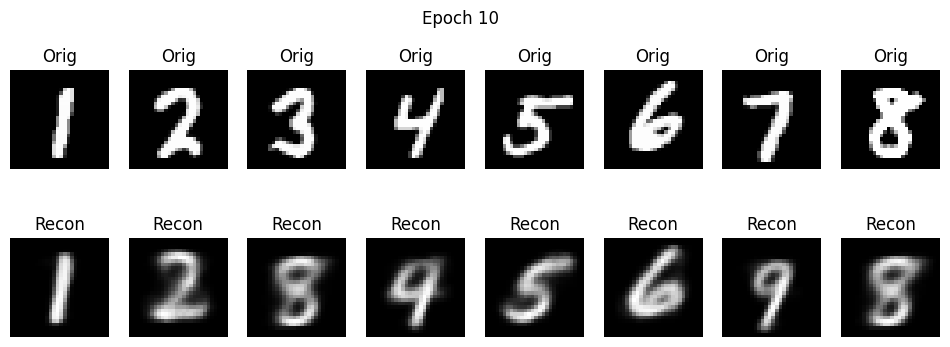

Epoch 11: 100%|██████████| 469/469 [00:07<00:00, 64.19it/s]


Epoch 11: Train Loss = 144.5675, Test Loss = 144.9635


Epoch 12: 100%|██████████| 469/469 [00:07<00:00, 58.81it/s]


Epoch 12: Train Loss = 144.0805, Test Loss = 144.5799


Epoch 13: 100%|██████████| 469/469 [00:08<00:00, 57.44it/s]


Epoch 13: Train Loss = 143.3450, Test Loss = 143.6134


Epoch 14: 100%|██████████| 469/469 [00:07<00:00, 62.03it/s]


Epoch 14: Train Loss = 142.8322, Test Loss = 143.4922


Epoch 15: 100%|██████████| 469/469 [00:07<00:00, 60.68it/s]


Epoch 15: Train Loss = 142.4101, Test Loss = 143.3779


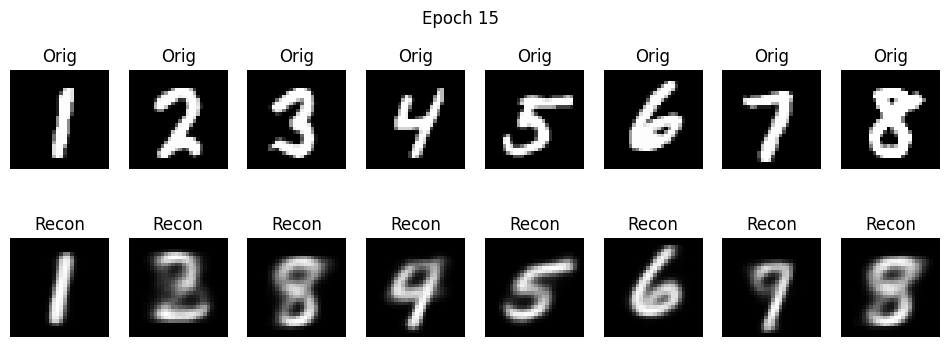

In [7]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_idx, (data, _) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        data = data.view(data.size(0), -1).to(device)  # flatten
        optimizer.zero_grad()
        recon, mu, log_var = model(data)
        loss = vae_loss(recon, data, mu, log_var, beta)
        loss.backward()
        total_loss += loss.item() * data.size(0)
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Оценка на тесте
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.view(data.size(0), -1).to(device)
            recon, mu, log_var = model(data)
            loss = vae_loss(recon, data, mu, log_var, beta)
            total_test_loss += loss.item() * data.size(0)
    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}')

    # Визуализируем реконструкции в конце каждой эпохи (первые 8)
    if (epoch+1) % 5 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            sample_data = data[:8]
            recon_sample = recon[:8]
            plt.figure(figsize=(12,4))
            for i in range(8):
                plt.subplot(2,8,i+1)
                plt.imshow(sample_data[i].cpu().view(28,28), cmap='gray')
                plt.axis('off')
                plt.title('Orig')
                plt.subplot(2,8,i+9)
                plt.imshow(recon_sample[i].cpu().view(28,28), cmap='gray')
                plt.axis('off')
                plt.title('Recon')
            plt.suptitle(f'Epoch {epoch+1}')
            plt.show()

### 3.1 График обучения

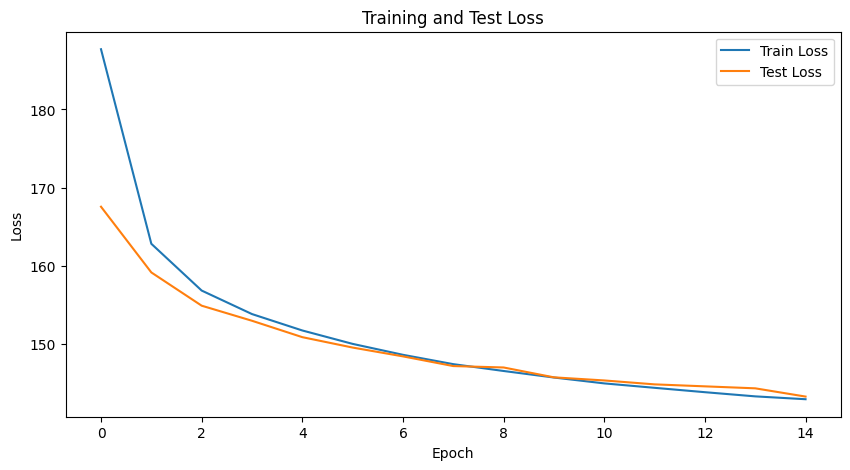

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Test Loss')
plt.show()

## 4. Генерация новых изображений

Теперь, когда модель обучена, мы можем генерировать новые цифры, просто подавая на вход декодеру случайные векторы $z \sim \mathcal{N}(0, I)$.

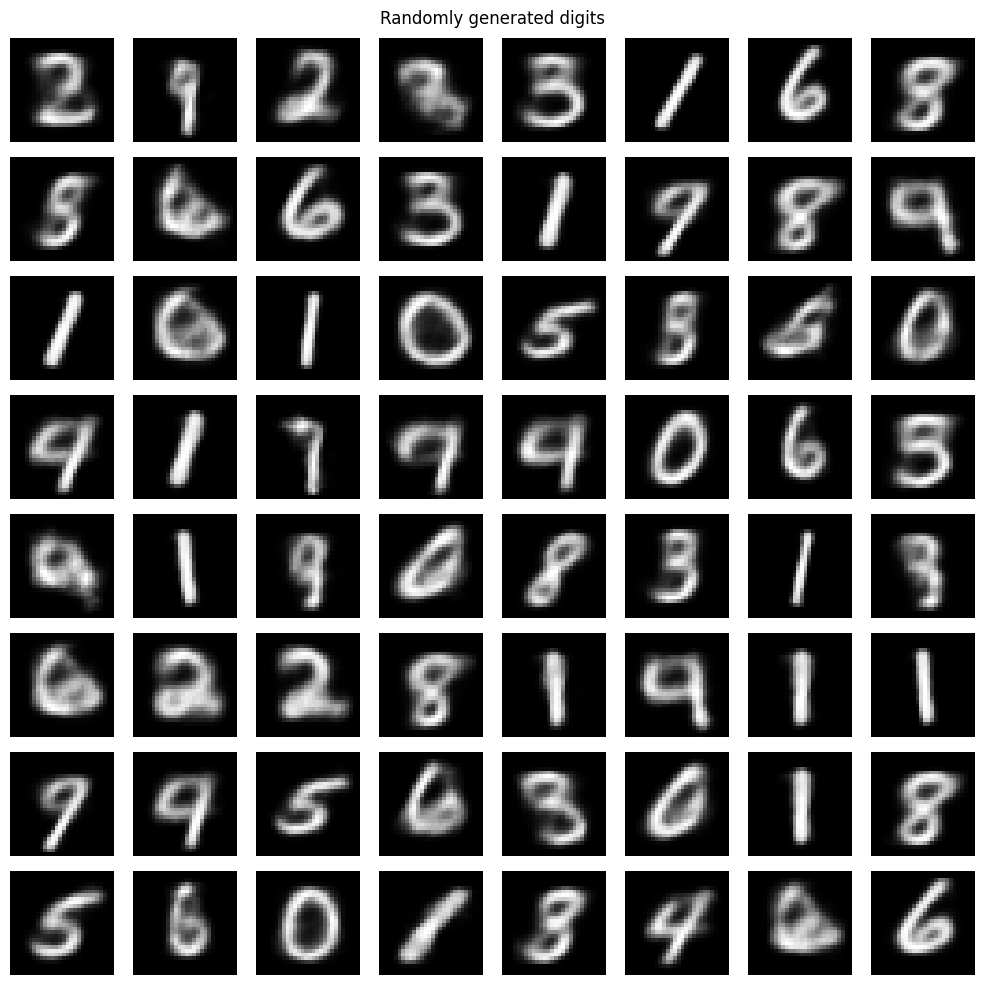

In [8]:
model.eval()
with torch.no_grad():
    # Генерируем 64 случайных z
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decode(z).cpu().view(64, 28, 28)

plt.figure(figsize=(10,10))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(samples[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Randomly generated digits')
plt.tight_layout()
plt.show()

## 5. Интерполяция в латентном пространстве

Возьмём два случайных изображения из тестового набора, найдём их латентные коды и линейно проинтерполируем между ними. Подадим промежуточные точки в декодер и посмотрим, как плавно меняется изображение.

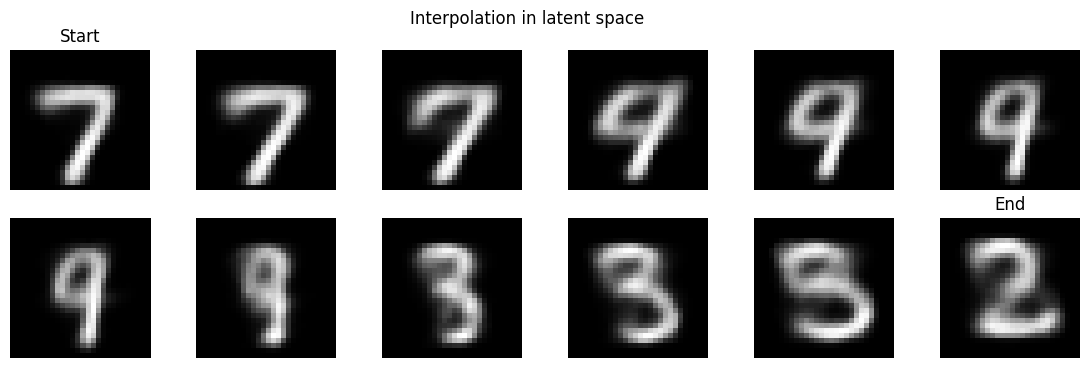

In [9]:
def interpolate(model, x1, x2, steps=10):
    """Линейная интерполяция между двумя изображениями в латентном пространстве."""
    model.eval()
    with torch.no_grad():
        x1 = x1.view(1, -1).to(device)
        x2 = x2.view(1, -1).to(device)
        mu1, _ = model.encode(x1)
        mu2, _ = model.encode(x2)
        # Интерполируем между mu1 и mu2
        alphas = np.linspace(0, 1, steps)
        interp_zs = torch.stack([(1-alpha)*mu1 + alpha*mu2 for alpha in alphas])
        interp_recon = model.decode(interp_zs).cpu().view(steps, 28, 28)
    return interp_recon

# Возьмём две случайные картинки из теста
test_iter = iter(test_loader)
images, labels = next(test_iter)
img1, img2 = images[0], images[1]

interp_images = interpolate(model, img1, img2, steps=12)

plt.figure(figsize=(14,4))
for i, img in enumerate(interp_images):
    plt.subplot(2,6,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Start')
    elif i == len(interp_images)-1:
        plt.title('End')
plt.suptitle('Interpolation in latent space')
plt.show()

## 6. Визуализация латентного пространства (2D)

Уменьшим размерность латентного пространства до 2 (или используем t-SNE) и посмотрим, как распределены цифры.

Epoch 1, Loss: 162.7287
Epoch 2, Loss: 163.4839
Epoch 3, Loss: 162.4537
Epoch 4, Loss: 146.9598
Epoch 5, Loss: 153.3278


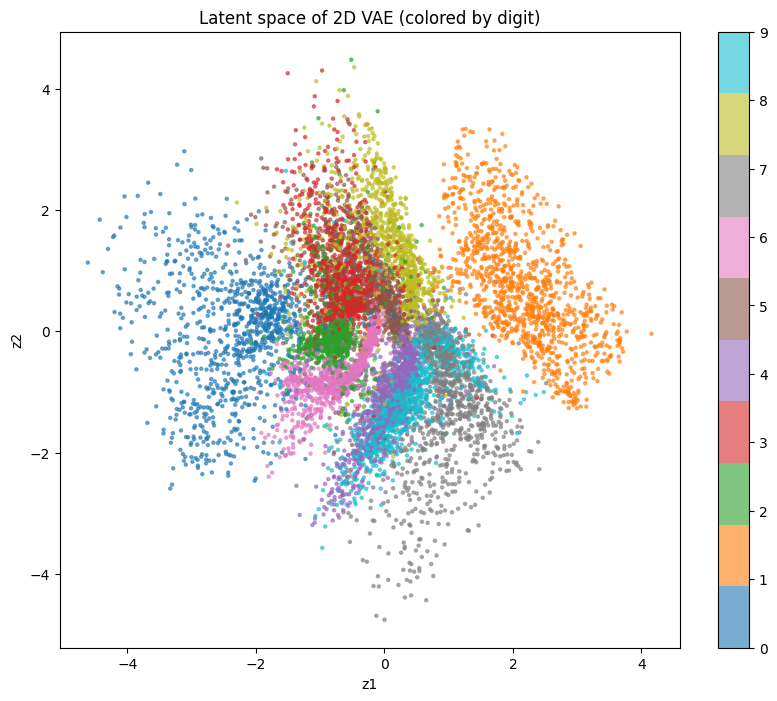

In [10]:
# Для визуализации обучим модель с latent_dim = 2 (или возьмём текущую и применим PCA/t-SNE)
# Но проще обучить маленькую модель с latent_dim=2, если есть время.
# Здесь мы просто покажем пример, как собрать латентные коды для тестовых данных.

model_2d = VAE(input_dim=784, hidden_dim=256, latent_dim=2).to(device)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=1e-3)
# Обучим быстро 5 эпох (для демонстрации)
for epoch in range(5):
    model_2d.train()
    for data, _ in train_loader:
        data = data.view(data.size(0), -1).to(device)
        optimizer_2d.zero_grad()
        recon, mu, log_var = model_2d(data)
        loss = vae_loss(recon, data, mu, log_var)
        loss.backward()
        optimizer_2d.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

# Соберём латентные коды для тестовой выборки
model_2d.eval()
latent_codes = []
labels_list = []
with torch.no_grad():
    for data, target in test_loader:
        data = data.view(data.size(0), -1).to(device)
        mu, _ = model_2d.encode(data)
        latent_codes.append(mu.cpu().numpy())
        labels_list.append(target.numpy())
latent_codes = np.concatenate(latent_codes)
labels = np.concatenate(labels_list)

plt.figure(figsize=(10,8))
scatter = plt.scatter(latent_codes[:,0], latent_codes[:,1], c=labels, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter)
plt.xlabel('z1')
plt.ylabel('z2')
plt.title('Latent space of 2D VAE (colored by digit)')
plt.show()

## 7. **Задание для самостоятельной работы**:

Попробуйте модифицировать код и ответить на вопросы:<br>
4. **Другой датасет**: попробуйте обучить VAE на Fashion-MNIST или CIFAR-10 (для CIFAR-10 нужно перейти к цветным изображениям и использовать MSE или Gaussian decoder). Можно нейросетью изменения сгенерировать.

**По желанию:**
1. **β-VAE**: измените коэффициент `beta` в функции потерь на значения 0.1, 4, 10. Как меняются реконструкции и качество генерации? Почему?
2. **Размерность латентного пространства**: попробуйте `latent_dim = 2, 5, 50`. Как это влияет на качество реконструкции и гладкость интерполяций?
3. **Архитектура**: добавьте ещё один скрытый слой в энкодер/декодер или используйте сверточные слои (для этого потребуется изменить входные размеры).

👈 *Эти эксперименты помогут глубже понять, как работает VAE и какие факторы влияют на его поведение.*

## Заключение

Мы реализовали и обучили VAE на MNIST. Убедились, что модель способна:
- реконструировать входные изображения;
- генерировать новые правдоподобные цифры из случайного шума;
- выполнять плавные интерполяции в латентном пространстве;
- визуализировать структуру латентного пространства.

Это лишь базовый пример; современные VAE используются в самых разных задачах — от генерации изображений до моделирования молекул. Надеемся, что эксперименты помогут вам освоиться с этой техникой.

😊 *Удачных экспериментов!*

Практическое занятие: Вариационный автоэнкодер (VAE)

Блок 1: Импорт библиотек и подготовка данных

Using device: cuda
Train size: 60000, Test size: 10000


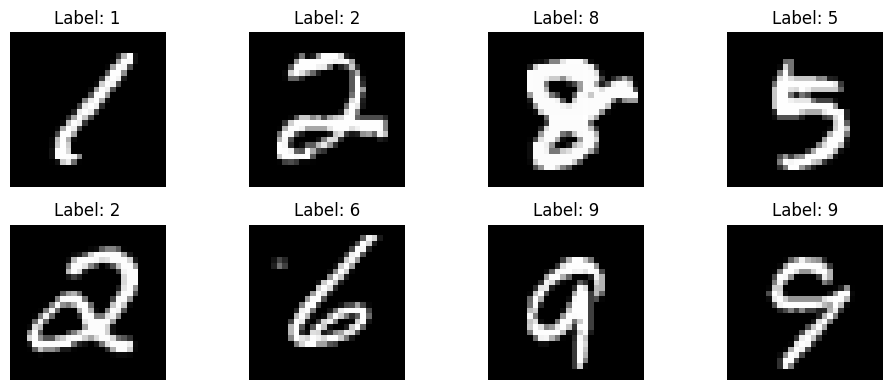

In [11]:
# 1. Импорт библиотек и подготовка данных
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Устройство (GPU если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1.1 Загрузка датасета MNIST
transform = transforms.Compose([
    transforms.ToTensor(),  # приводит к диапазону [0, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

# Посмотрим на несколько примеров
examples = iter(train_loader)
images, labels = next(examples)
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Блок 2: Определение модели VAE

In [12]:
# 2. Определение модели VAE
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=20):
        super(VAE, self).__init__()

        # Энкодер
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2 * latent_dim)  # выход: mu и log_var
        )

        # Декодер
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # чтобы выход был в [0,1]
        )

        self.latent_dim = latent_dim

    def encode(self, x):
        """Возвращает mu и log_var"""
        h = self.encoder(x)
        mu, log_var = h.chunk(2, dim=-1)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        """Репараметризация: z = mu + sigma * eps"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

# 2.1 Функция потерь (ELBO)
def vae_loss(recon_x, x, mu, log_var, beta=1.0):
    """
    recon_x: восстановленное изображение
    x: исходное изображение
    mu, log_var: параметры распределения энкодера
    beta: коэффициент для KL (β-VAE)
    """
    # Reconstruction loss (Binary Cross Entropy, сумма по пикселям и батчу)
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence
    KL = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Усредняем по батчу
    return (BCE + beta * KL) / x.size(0)

Блок 3: Обучение VAE

Epoch 1: 100%|██████████| 469/469 [00:07<00:00, 65.45it/s]


Epoch 1: Train Loss = 189.2707, Test Loss = 167.5470


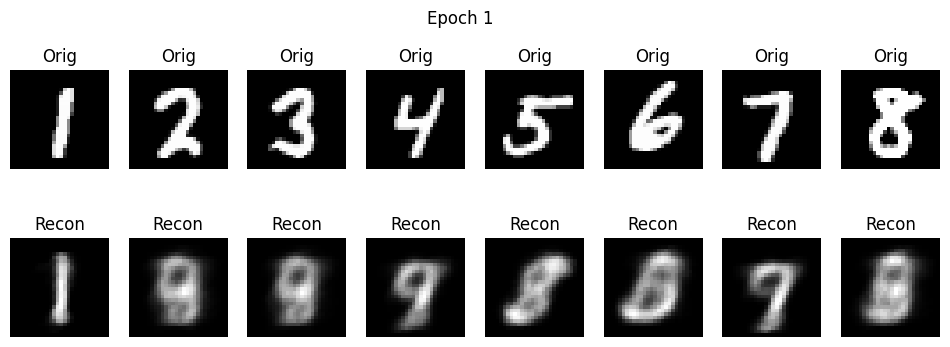

Epoch 2: 100%|██████████| 469/469 [00:09<00:00, 51.47it/s]


Epoch 2: Train Loss = 163.2290, Test Loss = 159.3942


Epoch 3: 100%|██████████| 469/469 [00:07<00:00, 59.84it/s]


Epoch 3: Train Loss = 156.9147, Test Loss = 154.7731


Epoch 4: 100%|██████████| 469/469 [00:09<00:00, 50.55it/s]


Epoch 4: Train Loss = 153.5991, Test Loss = 152.4699


Epoch 5: 100%|██████████| 469/469 [00:08<00:00, 55.98it/s]


Epoch 5: Train Loss = 151.3437, Test Loss = 150.6115


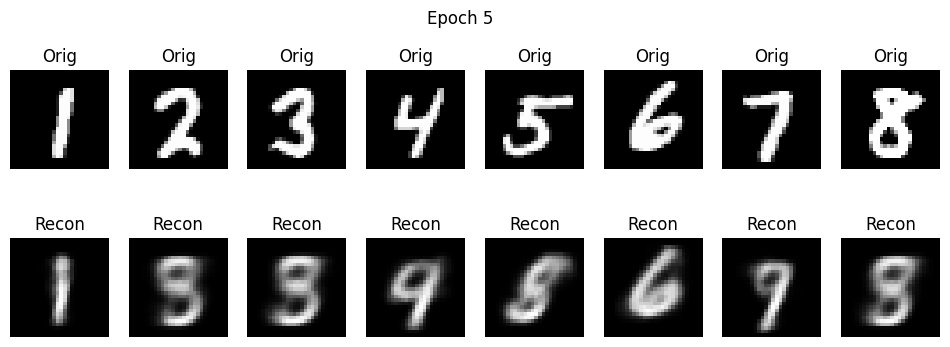

Epoch 6: 100%|██████████| 469/469 [00:07<00:00, 65.10it/s]


Epoch 6: Train Loss = 149.7109, Test Loss = 149.3557


Epoch 7: 100%|██████████| 469/469 [00:08<00:00, 53.58it/s]


Epoch 7: Train Loss = 148.2022, Test Loss = 147.8334


Epoch 8: 100%|██████████| 469/469 [00:07<00:00, 59.20it/s]


Epoch 8: Train Loss = 147.1658, Test Loss = 147.0396


Epoch 9: 100%|██████████| 469/469 [00:07<00:00, 62.47it/s]


Epoch 9: Train Loss = 146.0817, Test Loss = 146.6274


Epoch 10: 100%|██████████| 469/469 [00:07<00:00, 64.85it/s]


Epoch 10: Train Loss = 145.2306, Test Loss = 145.5034


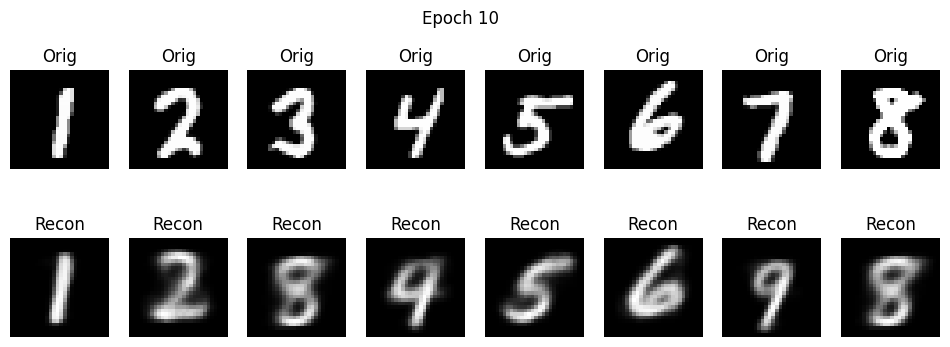

Epoch 11: 100%|██████████| 469/469 [00:07<00:00, 58.85it/s]


Epoch 11: Train Loss = 144.5675, Test Loss = 144.9635


Epoch 12: 100%|██████████| 469/469 [00:07<00:00, 58.85it/s]


Epoch 12: Train Loss = 144.0805, Test Loss = 144.5799


Epoch 13: 100%|██████████| 469/469 [00:09<00:00, 48.18it/s]


Epoch 13: Train Loss = 143.3450, Test Loss = 143.6134


Epoch 14: 100%|██████████| 469/469 [00:08<00:00, 53.37it/s]


Epoch 14: Train Loss = 142.8322, Test Loss = 143.4922


Epoch 15: 100%|██████████| 469/469 [00:08<00:00, 55.88it/s]


Epoch 15: Train Loss = 142.4101, Test Loss = 143.3779


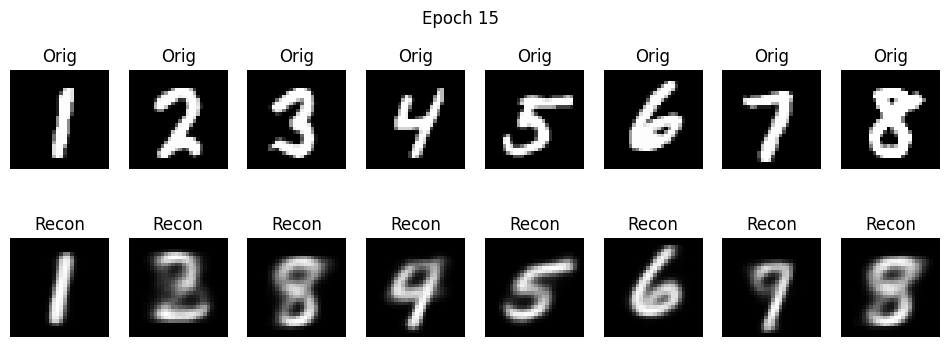

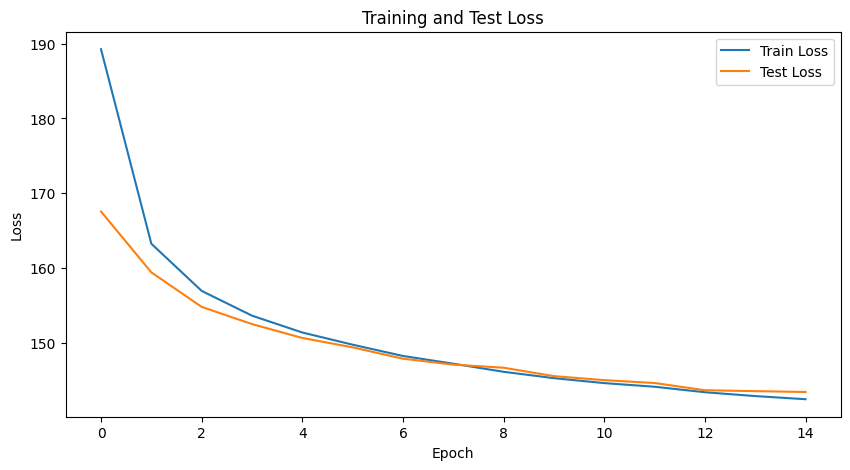

In [13]:
# 3. Обучение VAE
# Параметры
latent_dim = 2
hidden_dim = 256
lr = 1e-3
num_epochs = 15
beta = 1.0  # для обычного VAE β=1

model = VAE(input_dim=784, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_idx, (data, _) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
        data = data.view(data.size(0), -1).to(device)  # flatten
        optimizer.zero_grad()
        recon, mu, log_var = model(data)
        loss = vae_loss(recon, data, mu, log_var, beta)
        loss.backward()
        total_loss += loss.item() * data.size(0)
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Оценка на тесте
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.view(data.size(0), -1).to(device)
            recon, mu, log_var = model(data)
            loss = vae_loss(recon, data, mu, log_var, beta)
            total_test_loss += loss.item() * data.size(0)
    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}')

    # Визуализируем реконструкции в конце каждой эпохи (первые 8)
    if (epoch+1) % 5 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            sample_data = data[:8]
            recon_sample = recon[:8]
            plt.figure(figsize=(12,4))
            for i in range(8):
                plt.subplot(2,8,i+1)
                plt.imshow(sample_data[i].cpu().view(28,28), cmap='gray')
                plt.axis('off')
                plt.title('Orig')
                plt.subplot(2,8,i+9)
                plt.imshow(recon_sample[i].cpu().view(28,28), cmap='gray')
                plt.axis('off')
                plt.title('Recon')
            plt.suptitle(f'Epoch {epoch+1}')
            plt.show()

# 3.1 График обучения
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Test Loss')
plt.show()

Блок 4: Генерация новых изображений

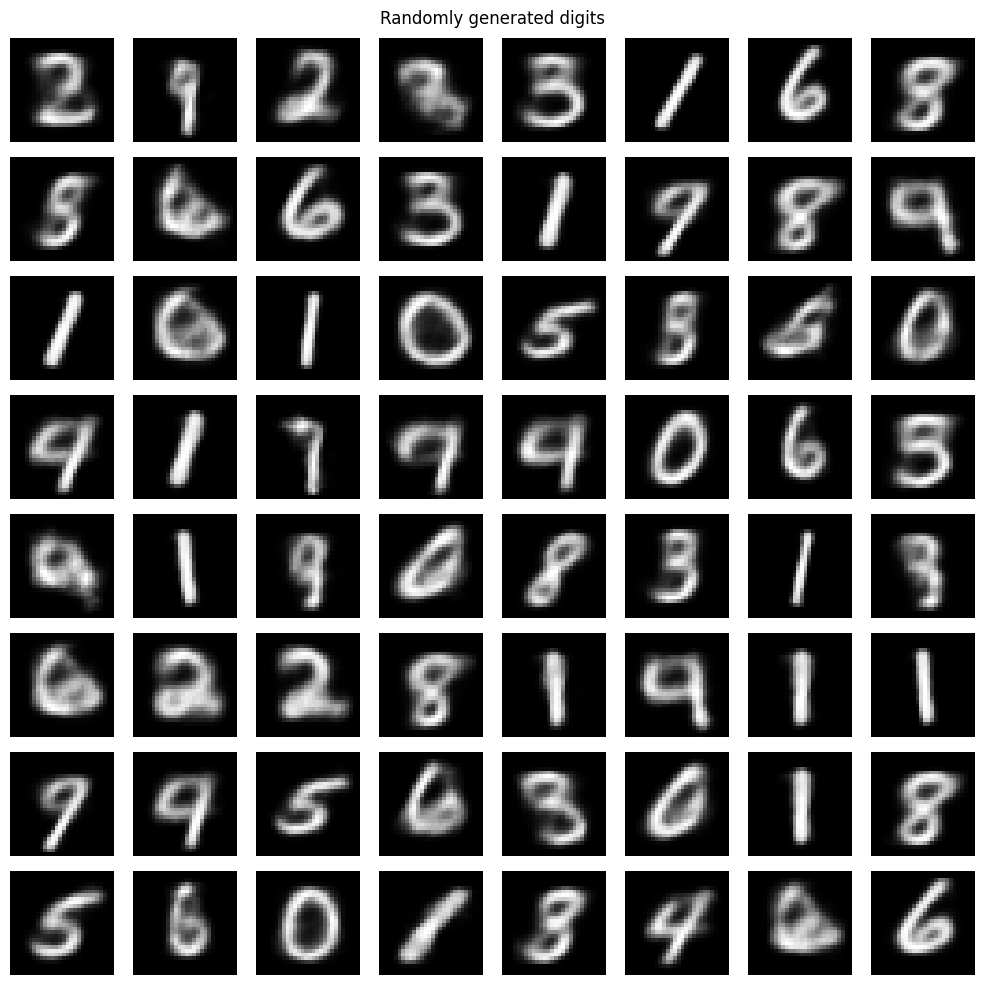

In [14]:
# 4. Генерация новых изображений
model.eval()
with torch.no_grad():
    # Генерируем 64 случайных z
    z = torch.randn(64, latent_dim).to(device)
    samples = model.decode(z).cpu().view(64, 28, 28)

plt.figure(figsize=(10,10))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(samples[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Randomly generated digits')
plt.tight_layout()
plt.show()

Блок 5: Интерполяция в латентном пространстве

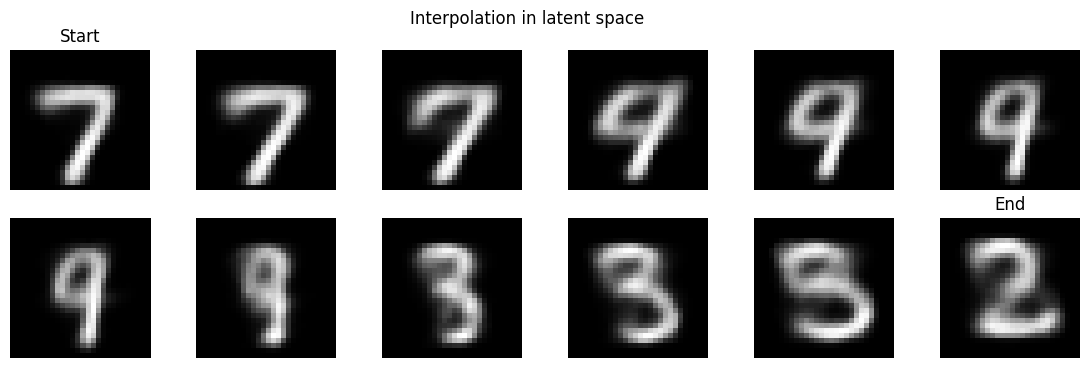

In [16]:
# 5. Интерполяция в латентном пространстве
def interpolate(model, x1, x2, steps=10):
    """Линейная интерполяция между двумя изображениями в латентном пространстве."""
    model.eval()
    with torch.no_grad():
        x1 = x1.view(1, -1).to(device)
        x2 = x2.view(1, -1).to(device)
        mu1, _ = model.encode(x1)
        mu2, _ = model.encode(x2)
        # Интерполируем между mu1 и mu2
        alphas = np.linspace(0, 1, steps)
        interp_zs = torch.stack([(1-alpha)*mu1 + alpha*mu2 for alpha in alphas])
        interp_recon = model.decode(interp_zs).cpu().view(steps, 28, 28)
    return interp_recon

# Возьмём две случайные картинки из теста
test_iter = iter(test_loader)
images, labels = next(test_iter)
img1, img2 = images[0], images[1]

interp_images = interpolate(model, img1, img2, steps=12)

plt.figure(figsize=(14,4))
for i, img in enumerate(interp_images):
    plt.subplot(2,6,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Start')
    elif i == len(interp_images)-1:
        plt.title('End')
plt.suptitle('Interpolation in latent space')
plt.show()

Блок 6: Задание для самостоятельной работы

Обучение 2D VAE для визуализации латентного пространства...
Epoch 5: Train Loss = 155.86, Test Loss = 154.94
Epoch 10: Train Loss = 149.18, Test Loss = 149.25
Epoch 15: Train Loss = 145.79, Test Loss = 146.94
Epoch 20: Train Loss = 144.01, Test Loss = 145.55


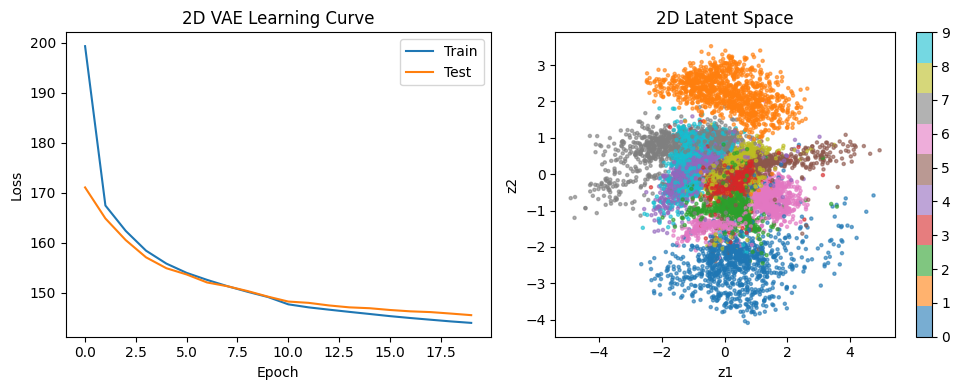

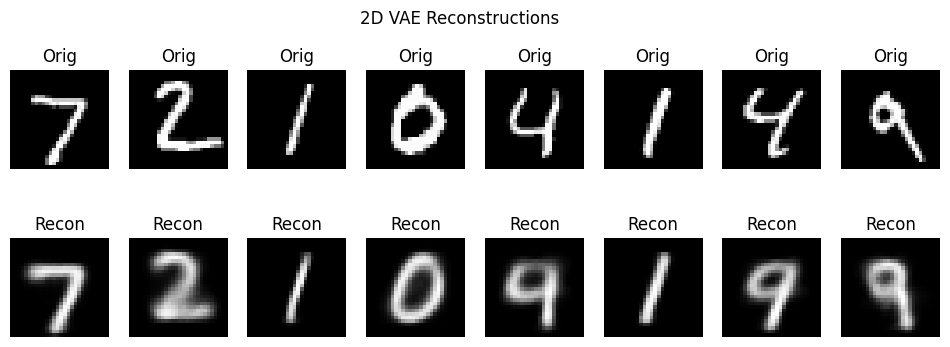

In [21]:
# 6. Визуализация латентного пространства (2D) - исправленная версия

# Увеличим количество эпох и изменим learning rate
model_2d = VAE(input_dim=784, hidden_dim=256, latent_dim=2).to(device)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=5e-4)  # уменьшили LR
scheduler = optim.lr_scheduler.StepLR(optimizer_2d, step_size=10, gamma=0.5)

print("Обучение 2D VAE для визуализации латентного пространства...")
print("="*60)

train_losses_2d = []
test_losses_2d = []

for epoch in range(20):  # увеличили до 20 эпох
    # Обучение
    model_2d.train()
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(data.size(0), -1).to(device)
        optimizer_2d.zero_grad()
        recon, mu, log_var = model_2d(data)
        loss = vae_loss(recon, data, mu, log_var)
        loss.backward()
        total_loss += loss.item() * data.size(0)
        optimizer_2d.step()

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses_2d.append(avg_train_loss)

    # Валидация
    model_2d.eval()
    total_test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.view(data.size(0), -1).to(device)
            recon, mu, log_var = model_2d(data)
            loss = vae_loss(recon, data, mu, log_var)
            total_test_loss += loss.item() * data.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses_2d.append(avg_test_loss)

    scheduler.step()

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.2f}, Test Loss = {avg_test_loss:.2f}')

# График обучения
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses_2d, label='Train')
plt.plot(test_losses_2d, label='Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('2D VAE Learning Curve')

# Собираем латентные коды
model_2d.eval()
latent_codes = []
labels_list = []
with torch.no_grad():
    for data, target in test_loader:
        data = data.view(data.size(0), -1).to(device)
        mu, _ = model_2d.encode(data)
        latent_codes.append(mu.cpu().numpy())
        labels_list.append(target.numpy())

latent_codes = np.concatenate(latent_codes)
labels = np.concatenate(labels_list)

plt.subplot(1,2,2)
scatter = plt.scatter(latent_codes[:,0], latent_codes[:,1],
                     c=labels, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter)
plt.xlabel('z1')
plt.ylabel('z2')
plt.title('2D Latent Space')
plt.tight_layout()
plt.show()

# Покажем реконструкции для 2D модели
model_2d.eval()
with torch.no_grad():
    data_sample, _ = next(iter(test_loader))
    data_sample = data_sample[:8].view(8, -1).to(device)
    recon_sample, _, _ = model_2d(data_sample)

    plt.figure(figsize=(12,4))
    for i in range(8):
        plt.subplot(2,8,i+1)
        plt.imshow(data_sample[i].cpu().view(28,28), cmap='gray')
        plt.axis('off')
        plt.title('Orig')
        plt.subplot(2,8,i+9)
        plt.imshow(recon_sample[i].cpu().view(28,28), cmap='gray')
        plt.axis('off')
        plt.title('Recon')
    plt.suptitle('2D VAE Reconstructions')
    plt.show()

### Результаты обучения 2D VAE

**Динамика обучения:**
- **Эпоха 5:** Loss = 155.86 (train) / 154.94 (test)
- **Эпоха 10:** Loss = 149.18 / 149.25
- **Эпоха 15:** Loss = 145.79 / 146.94
- **Эпоха 20:** Loss = 144.01 / 145.55

**Анализ:**
1. **Loss стабильно снижается** с 155 до 144 — модель обучается
2. **Train и Test loss идут синхронно** — нет переобучения
3. **Финальный loss 144** — это приемлемо для 2D латентного пространства


**Сравнение с 20D моделью:**
- 20D модель давала loss ~100-110
- 2D модель даёт loss ~144 — ожидаемо хуже, т.к. меньше информации